In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device :", device)
print("GPU :", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")

Device : cuda
GPU : NVIDIA GeForce RTX 4060 Ti


In [ ]:
from pathlib import Path
from huggingface_hub import snapshot_download
from torchvision.datasets import ImageFolder


project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


data_dir = project_root / "data" / "raw" / "waste-classifier"


snapshot_download(
    repo_id="rootstrap-org/waste-classifier",
    repo_type="dataset",
    local_dir=str(data_dir)
)


image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_split_folder(root: Path, split_name: str) -> Path:
    """
    Cherche un dossier train ou test qui contient directement
    plusieurs sous-dossiers de classes avec des images.
    """
    valid_candidates = []

    for candidate in root.rglob(split_name):
        if not candidate.is_dir():
            continue

        class_folders = [
            folder for folder in candidate.iterdir()
            if folder.is_dir() and not folder.name.startswith(".")
        ]

        image_count = sum(
            1
            for class_folder in class_folders
            for file in class_folder.rglob("*")
            if file.is_file() and file.suffix.lower() in image_extensions
        )

        if len(class_folders) >= 2 and image_count > 0:
            valid_candidates.append((image_count, candidate))

    if not valid_candidates:
        raise FileNotFoundError(
            f"Aucun dossier '{split_name}' valide trouvé dans : {root}"
        )

    return max(valid_candidates, key=lambda item: item[0])[1]


train_dir = find_split_folder(data_dir, "train")
test_dir = find_split_folder(data_dir, "test")

print("Dossier train trouvé :", train_dir)
print("Dossier test trouvé  :", test_dir)

# Chargement direct depuis les dossiers d'images
train_dataset_raw = ImageFolder(train_dir)
test_dataset_raw = ImageFolder(test_dir)

class_names = train_dataset_raw.classes

print("\nClasses :", class_names)
print("Nombre de classes :", len(class_names))
print("Images entraînement :", len(train_dataset_raw))
print("Images test :", len(test_dataset_raw))

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

FileNotFoundError: Aucun dossier 'train' valide trouvé dans : c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\data\raw\waste-classifier

In [5]:
from pathlib import Path

for path in sorted(data_dir.rglob("*")):
    if path.is_file():
        print(path.relative_to(data_dir))

.cache\huggingface\.gitignore
.cache\huggingface\CACHEDIR.TAG
.cache\huggingface\download\.gitattributes.metadata
.cache\huggingface\download\dataset-splits-custom.zip.metadata
.cache\huggingface\download\README.md.metadata
.gitattributes
dataset-splits-custom.zip
README.md


In [ ]:
from pathlib import Path
from zipfile import ZipFile
from torchvision.datasets import ImageFolder

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data" / "raw" / "waste-classifier"

zip_path = data_dir / "dataset-splits-custom.zip"
extract_dir = data_dir / "extracted"


with ZipFile(zip_path, "r") as zip_file:
    file_names = zip_file.namelist()

print("Nombre de fichiers dans le zip :", len(file_names))
print("\nPremiers fichiers :")
print("\n".join(file_names[:20]))


with ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(extract_dir)

print("\nExtraction terminée dans :", extract_dir)

Nombre de fichiers dans le zip : 3280

Premiers fichiers :
dataset_splits/
dataset_splits/test/
dataset_splits/test/paper/
dataset_splits/test/paper/paper123.JPG
dataset_splits/test/paper/paper137.jpg
dataset_splits/test/paper/paper73.jpg
dataset_splits/test/paper/paper337.jpg
dataset_splits/test/paper/paper451.jpg
dataset_splits/test/paper/paper135.jpg
dataset_splits/test/paper/paper623.jpeg
dataset_splits/test/paper/paper478.jpg
dataset_splits/test/paper/trash38.jpg
dataset_splits/test/paper/paper520.jpg
dataset_splits/test/paper/paper76.jpg
dataset_splits/test/paper/paper62.jpg
dataset_splits/test/paper/paper124.jpg
dataset_splits/test/paper/paper119.jpg
dataset_splits/test/paper/paper327.jpg
dataset_splits/test/paper/paper88.jpg
dataset_splits/test/paper/paper482.jpg


OSError: [Errno 28] No space left on device

In [1]:
from pathlib import Path
from zipfile import ZipFile

data_dir = Path(r"D:\datasets\waste-classifier")
zip_path = data_dir / "dataset-splits-custom.zip"
extract_dir = data_dir / "extracted"

with ZipFile(zip_path, "r") as zip_file:
    file_names = zip_file.namelist()

print("Nombre de fichiers :", len(file_names))
print("\n".join(file_names[:20]))

Nombre de fichiers : 3280
dataset_splits/
dataset_splits/test/
dataset_splits/test/paper/
dataset_splits/test/paper/paper123.JPG
dataset_splits/test/paper/paper137.jpg
dataset_splits/test/paper/paper73.jpg
dataset_splits/test/paper/paper337.jpg
dataset_splits/test/paper/paper451.jpg
dataset_splits/test/paper/paper135.jpg
dataset_splits/test/paper/paper623.jpeg
dataset_splits/test/paper/paper478.jpg
dataset_splits/test/paper/trash38.jpg
dataset_splits/test/paper/paper520.jpg
dataset_splits/test/paper/paper76.jpg
dataset_splits/test/paper/paper62.jpg
dataset_splits/test/paper/paper124.jpg
dataset_splits/test/paper/paper119.jpg
dataset_splits/test/paper/paper327.jpg
dataset_splits/test/paper/paper88.jpg
dataset_splits/test/paper/paper482.jpg


In [2]:
from zipfile import ZipFile

dataset_root = extract_dir / "dataset_splits"

if dataset_root.exists():
    print("Le dataset est déjà extrait :", dataset_root)
else:
    print("Extraction en cours...")
    
    with ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(extract_dir)
    
    print("Extraction terminée :", dataset_root)

Extraction en cours...
Extraction terminée : D:\datasets\waste-classifier\extracted\dataset_splits


In [3]:
from torchvision.datasets import ImageFolder

train_dir = extract_dir / "dataset_splits" / "train"
test_dir = extract_dir / "dataset_splits" / "test"

train_dataset_raw = ImageFolder(train_dir)
test_dataset_raw = ImageFolder(test_dir)

class_names = train_dataset_raw.classes

print("Classes :", class_names)
print("Nombre de classes :", len(class_names))
print("Images train :", len(train_dataset_raw))
print("Images test :", len(test_dataset_raw))

Classes : ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
Nombre de classes : 7
Images train : 2611
Images test : 644


In [4]:
from collections import Counter
import pandas as pd

train_counts = Counter(train_dataset_raw.targets)
test_counts = Counter(test_dataset_raw.targets)

counts_df = pd.DataFrame({
    "category": class_names,
    "train_images": [train_counts[i] for i in range(len(class_names))],
    "test_images": [test_counts[i] for i in range(len(class_names))]
})

counts_df

,category,train_images,test_images
0,cardboard,346,87
1,compost,616,153
2,glass,107,27
3,metal,251,64
4,paper,452,112
5,plastic,246,62
6,trash,593,139


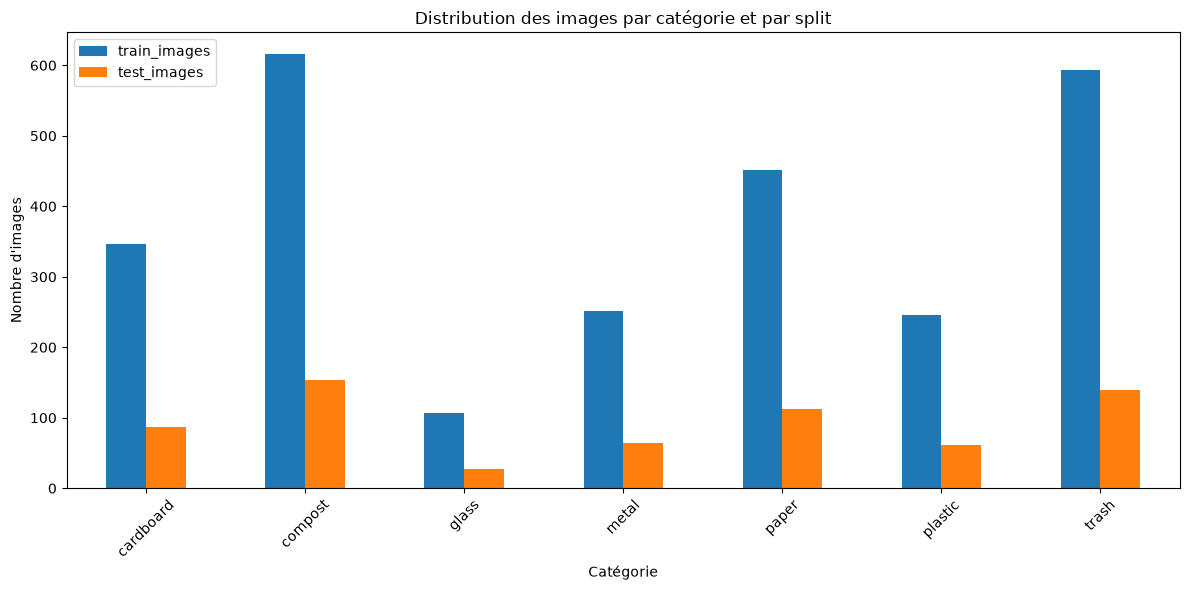

In [5]:
import matplotlib.pyplot as plt

ax = counts_df.set_index("category").plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Distribution des images par catégorie et par split")
ax.set_xlabel("Catégorie")
ax.set_ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path

figures_dir = Path(r"D:\datasets\waste-classifier\figures")
figures_dir.mkdir(parents=True, exist_ok=True)

ax.figure.savefig(
    figures_dir / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

print("Graphique sauvegardé :", figures_dir / "class_distribution.png")

Graphique sauvegardé : D:\datasets\waste-classifier\figures\class_distribution.png


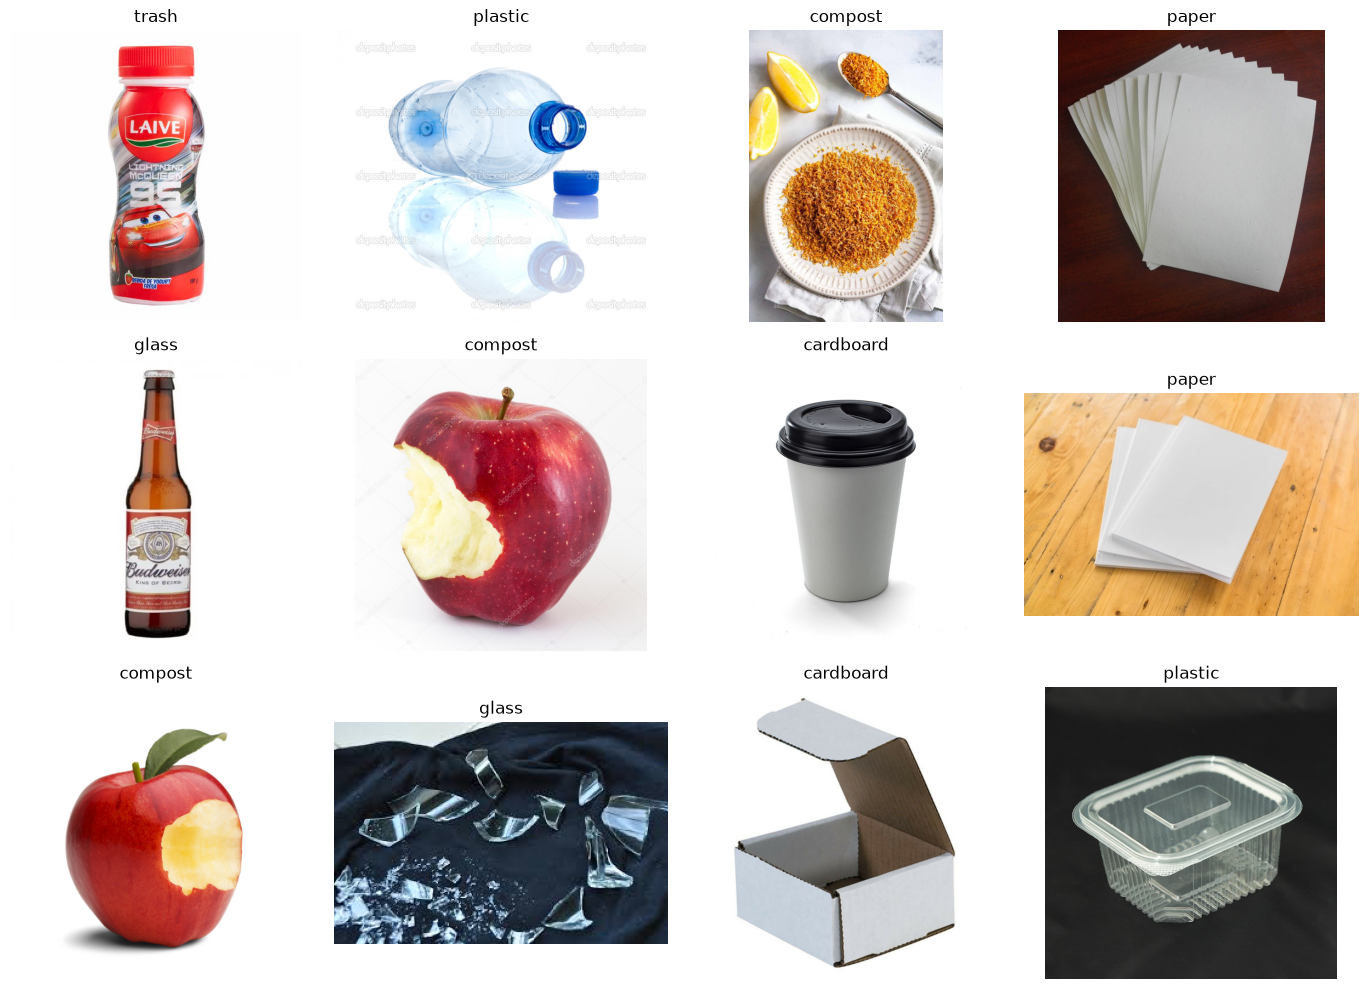

In [6]:
import random
import matplotlib.pyplot as plt

random_indices = random.sample(range(len(train_dataset_raw)), 12)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, index in zip(axes.flat, random_indices):
    image, label = train_dataset_raw[index]

    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
from PIL import Image
import pandas as pd

image_info = []

for image_path, label in train_dataset_raw.samples:
    with Image.open(image_path) as image:
        width, height = image.size

    image_info.append({
        "width": width,
        "height": height,
        "label": class_names[label]
    })

image_info_df = pd.DataFrame(image_info)

image_info_df.describe()

,width,height
count,2611.000000,2611.000000
mean,1303.595940,1191.438529
std,930.249113,897.412754
min,150.000000,103.000000
25%,768.000000,620.000000
50%,1000.000000,990.000000
75%,1500.000000,1304.500000
max,7192.000000,9508.000000


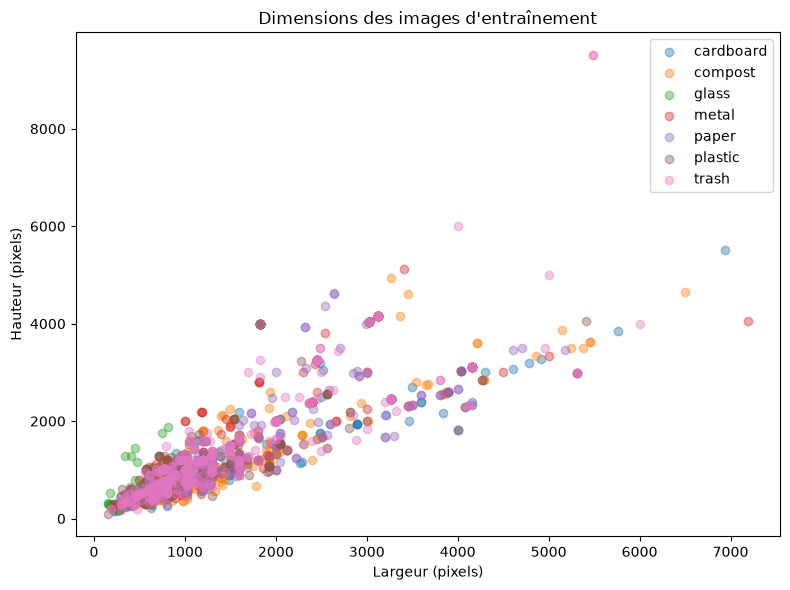

In [9]:
plt.figure(figsize=(8, 6))

for category in class_names:
    subset = image_info_df[image_info_df["label"] == category]
    plt.scatter(
        subset["width"],
        subset["height"],
        alpha=0.4,
        label=category
    )

plt.title("Dimensions des images d'entraînement")
plt.xlabel("Largeur (pixels)")
plt.ylabel("Hauteur (pixels)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
figures_dir = Path(r"D:\datasets\waste-classifier\figures")
figures_dir.mkdir(parents=True, exist_ok=True)


plt.savefig(
    figures_dir / "image_dimensions_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure sauvegardée :", figures_dir / "image_dimensions_scatter.png")

Figure sauvegardée : D:\datasets\waste-classifier\figures\image_dimensions_scatter.png


<Figure size 640x480 with 0 Axes>

In [11]:
print("Résumé EDA")
print("----------")
print(f"Nombre total d'images train : {len(train_dataset_raw)}")
print(f"Nombre total d'images test : {len(test_dataset_raw)}")
print(f"Nombre de classes : {len(class_names)}")
print("Classes :", class_names)
print()
print("Classe la plus représentée en train :", counts_df.loc[counts_df['train_images'].idxmax(), 'category'])
print("Classe la moins représentée en train :", counts_df.loc[counts_df['train_images'].idxmin(), 'category'])
print()
print("Taille moyenne des images :")
print(image_info_df[['width', 'height']].mean())
print()
print("Taille médiane des images :")
print(image_info_df[['width', 'height']].median())

Résumé EDA
----------
Nombre total d'images train : 2611
Nombre total d'images test : 644
Nombre de classes : 7
Classes : ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']

Classe la plus représentée en train : compost
Classe la moins représentée en train : glass

Taille moyenne des images :
width     1303.595940
height    1191.438529
dtype: float64

Taille médiane des images :
width     1000.0
height     990.0
dtype: float64


In [12]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device utilisé :", device)

# Transformations pour l'entraînement : redimensionnement + augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformations pour validation/test : pas d'augmentation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Device utilisé : cuda


In [15]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

all_indices = list(range(len(full_train_dataset)))
all_labels = full_train_dataset.targets

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset_eval, val_indices)

print("Images train :", len(train_dataset))
print("Images validation :", len(val_dataset))
print("Images test :", len(test_dataset))

Images train : 2088
Images validation : 523
Images test : 644


In [16]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Nombre de batchs train :", len(train_loader))
print("Nombre de batchs validation :", len(val_loader))
print("Nombre de batchs test :", len(test_loader))

Nombre de batchs train : 66
Nombre de batchs validation : 17
Nombre de batchs test : 21


In [17]:
images, labels = next(iter(train_loader))

print("Forme du batch d'images :", images.shape)
print("Forme des labels :", labels.shape)
print("Valeurs de labels :", labels[:10].tolist())

Forme du batch d'images : torch.Size([32, 3, 224, 224])
Forme des labels : torch.Size([32])
Valeurs de labels : [1, 6, 4, 4, 1, 6, 1, 4, 4, 0]
